In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

In [3]:
class HEMSEnvForGAOptimization(gym.Env):
    """The HEMS environment with data handling and net metering Draft."""
    metadata = {"render.modes": ["human"]}

    def __init__(self, config):
        super().__init__()
        # ---DATA LOADING ---
        self.solar_df = pd.read_csv(config["solar_path"], parse_dates=["time"])
        self.load_df = pd.read_csv(config["load_path"], parse_dates=["Date_Time"])
        self.solar_df.columns = self.solar_df.columns.str.strip()
        self.load_df.columns = self.load_df.columns.str.strip()
        
        cols_to_convert = ['Laundary_kW', 'Kitchen_light1_kW', 'AC_BR_kW', 'AC_GR_kW', 'SR_kW', 'Refrigerator_kW', 'Kitchen_light2_kW', 'AC_kW', 'AC_MBR_kW', 'WP_kW', 'WD_kW']
        for col in cols_to_convert:
            if col in self.load_df.columns:
                self.load_df[col] = pd.to_numeric(self.load_df[col], errors='coerce')
        self.load_df.fillna(0, inplace=True)
        
        self.config = config
        self.solar_panel_area = config["solar_panel_area"]
        self.max_battery = float(config["max_battery_kwh"])
        self.appliances = config["appliances"]
        self.feed_in_tariff = config.get("feed_in_tariff", 12.0)
        
        self.w_grid_cost = config["reward_weights"]["grid"]
        self.w_battery_deg = config["reward_weights"]["battery_deg"]
        self.w_comfort = config["reward_weights"]["comfort"]
        
        self.n_steps = min(len(self.load_df), len(self.solar_df))
        self.dt_hours = 1 / 60.0
        self.steps_per_day = 24 * 60

        self.action_space = spaces.Discrete(2**len(self.appliances))
        num_obs_features = 4 + len(self.appliances)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(num_obs_features,), dtype=np.float32)
        
        self.time_step = 0
        self.battery_soc = 0.0
        self._reset_appliance_states()

    def _reset_appliance_states(self):
        self.appliance_states = [{"name": app["name"], "is_running": False, "steps_remaining": 0, "task_completed_today": False} for app in self.appliances]

    def _compute_solar_output_kw(self, solar_row):
        ghi = pd.to_numeric(solar_row.get("ghi_pyr"), errors='coerce')
        humidity = pd.to_numeric(solar_row.get("relative_humidity"), errors='coerce')
        if pd.isna(ghi) or pd.isna(humidity): return 0.0
        panel_efficiency = 0.18
        weather_factor = max(0.0, 1.0 - (humidity / 100.0))
        pv_kw = (ghi * self.solar_panel_area * panel_efficiency * weather_factor) / 1000.0
        return max(pv_kw, 0.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.time_step = 0
        self.battery_soc = 0.5 * self.max_battery
        self._reset_appliance_states()
        obs, info = self._get_obs()
        return obs, info

    def _get_obs(self):
        idx = self.time_step % self.n_steps
        solar_row = self.solar_df.iloc[idx]
        solar_kw = self._compute_solar_output_kw(solar_row)
        soc_norm = self.battery_soc / self.max_battery if self.max_battery > 0 else 0.0
        hour = (self.time_step // 60) % 24
        hour_rad = (2.0 * math.pi * hour) / 24.0
        appliance_statuses = [1.0 if not s["task_completed_today"] else 0.0 for s in self.appliance_states]
        obs_list = [solar_kw, soc_norm, math.sin(hour_rad), math.cos(hour_rad)] + appliance_statuses
        return np.array(obs_list, dtype=np.float32), {}

    def _get_grid_price_for_hour(self, hour):
        return 46.85 if 19 <= hour <= 23 else 40.53

    def step(self, action):
        idx = self.time_step % self.n_steps
        current_load_row = self.load_df.iloc[idx]
        
        if self.time_step > 0 and self.time_step % self.steps_per_day == 0:
            for state in self.appliance_states:
                state["task_completed_today"] = False

        action_commands = [int(bit) for bit in np.binary_repr(action, width=len(self.appliances))]
        appliance_load_kw = 0
        for i, start_command in enumerate(action_commands):
            state = self.appliance_states[i]
            if start_command == 1 and not state["is_running"] and not state["task_completed_today"]:
                state["is_running"] = True
                state["steps_remaining"] = self.appliances[i]["duration_steps"]
                state["task_completed_today"] = True
            if state["is_running"]:
                appliance_load_kw += self.appliances[i]["power_kw"]
                state["steps_remaining"] -= 1
                if state["steps_remaining"] == 0: state["is_running"] = False

        base_load_kw = current_load_row['Refrigerator_kW'] + current_load_row['WD_kW'] + current_load_row['Kitchen_light1_kW'] + current_load_row['Kitchen_light2_kW'] + current_load_row['SR_kW']
        total_load_kwh = (base_load_kw + appliance_load_kw) * self.dt_hours
        
        solar_row = self.solar_df.iloc[idx]
        solar_kwh_available = self._compute_solar_output_kw(solar_row) * self.dt_hours
        
        grid_energy_import, battery_discharge, grid_export_kwh = 0.0, 0.0, 0.0
        remaining_load = total_load_kwh
        solar_to_load = min(solar_kwh_available, remaining_load)
        remaining_load -= solar_to_load
        
        if self.battery_soc > 0 and remaining_load > 0:
            discharge = min(self.battery_soc, remaining_load / 0.95)
            battery_discharge = discharge
            self.battery_soc -= discharge
            remaining_load -= discharge * 0.95
        
        if remaining_load > 0:
            grid_energy_import = remaining_load
        
        excess_solar = solar_kwh_available - solar_to_load
        if excess_solar > 0:
            charge = min(excess_solar * 0.95, self.max_battery - self.battery_soc)
            self.battery_soc += charge
            remaining_excess = excess_solar - (charge / 0.95)
            if remaining_excess > 0:
                grid_export_kwh = remaining_excess

        hour = (self.time_step // 60) % 24
        grid_cost = grid_energy_import * self._get_grid_price_for_hour(hour)
        grid_revenue = grid_export_kwh * self.feed_in_tariff
        battery_deg_cost = battery_discharge * self.config.get("battery_deg_cost_per_kwh", 0.01)
        
        comfort_penalty = 0
        missed_task_today = False
        if (self.time_step + 1) % self.steps_per_day == 0:
            if not all(s["task_completed_today"] for s in self.appliance_states):
                comfort_penalty = 1
                missed_task_today = True
        
        reward = -((self.w_grid_cost * grid_cost) + (self.w_battery_deg * battery_deg_cost) + (self.w_comfort * comfort_penalty)) + grid_revenue
        
        terminated = self.time_step >= (self.n_steps - 1)
        # --- Corrected info dictionary ---
        solar_kw_now = self._compute_solar_output_kw(solar_row) # First, calculate the current solar kW

        info = { 
        "total_cost": grid_cost + battery_deg_cost, 
        "grid_revenue": grid_revenue, 
        "task_missed": missed_task_today, 
        "appliance_load_kw": appliance_load_kw, 
        "base_load_kw": base_load_kw, 
        "solar_kw": solar_kw_now, # Use the correctly calculated variable
        "battery_soc": self.battery_soc,
         "running_appliances": [s["is_running"] for s in self.appliance_states] # Add the missing key
        }
        self.time_step += 1
        obs, _ = self._get_obs()
        return obs, reward, terminated, False, info

In [4]:
def analyze_and_define_jobs(data_path):
    """Analyzes the detailed load data to define schedulable jobs."""
    print("--- Analyzing dataset to define appliance jobs ---")
    df = pd.read_csv(data_path)
    df.columns = df.columns.str.strip()
    
    cols_to_convert = ['Laundary_kW', 'AC_BR_kW', 'AC_GR_kW','AC_MBR_kW', 'WP_kW', "AC_kW"]
    for col in cols_to_convert:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df.fillna(0, inplace=True)
    
    appliances = []
    print("Defined Jobs:")
    for col in cols_to_convert:
        if col in df.columns:
            power_draw = df[df[col] > 0.1][col].mean()
            df['running'] = (df[col] > 0.1).astype(int)
            df['block'] = (df['running'].diff() != 0).astype(int).cumsum()
            run_lengths = df[df['running'] == 1].groupby('block').size()
            
            duration = max(45, run_lengths.median()) if not run_lengths.empty else 90
            
            if pd.notna(power_draw) and power_draw > 0.1:
                 job = {"name": col, "power_kw": power_draw, "duration_steps": int(duration)}
                 appliances.append(job)
                 print(f"  - {job['name']}: {job['power_kw']:.2f} kW for {job['duration_steps']} minutes")
                 
    print("--- Job definitions complete ---\n")
    return appliances

# Run the analysis
appliance_jobs = analyze_and_define_jobs("homee.csv")

--- Analyzing dataset to define appliance jobs ---
Defined Jobs:
  - Laundary_kW: 0.68 kW for 45 minutes
  - AC_BR_kW: 0.61 kW for 45 minutes
  - AC_GR_kW: 0.49 kW for 45 minutes
  - AC_MBR_kW: 0.81 kW for 45 minutes
  - WP_kW: 0.17 kW for 45 minutes
  - AC_kW: 1.19 kW for 145 minutes
--- Job definitions complete ---



In [17]:
# --- Main Configuration for all Experiments ---
base_config = {
    "load_path": "homee.csv",
    "solar_path": "solar.csv", 
    "solar_panel_area": 27.8,  # 5 kW
    "max_battery_kwh": 10.0,   # 10 kWh battery
    "appliances": appliance_jobs,
    "feed_in_tariff": 12.0
}

# --- Parameters for the GA and Final RL Agent ---
GA_GENERATIONS = 20
GA_POPULATION_SIZE = 20
RL_FITNESS_TIMESTEPS = 50000
FINAL_AGENT_TRAINING_TIMESTEPS = 300000

In [18]:
def run_rl_for_fitness(config, training_timesteps):
    """The GA's fitness function: trains and evaluates an RL agent."""
    try:
        def make_env(): return HEMSEnvForGAOptimization(config)
        vec_env = DummyVecEnv([make_env])
        vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=False, clip_obs=10.0)
        model = PPO("MlpPolicy", vec_env, verbose=0)
        model.learn(total_timesteps=training_timesteps)
        
        all_infos = []
        obs = vec_env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, terminated, info = vec_env.step(action)
            all_infos.append(info[0])
            done = terminated[0]
            
        results = pd.DataFrame(all_infos)
        net_cost = results['total_cost'].sum() - results['grid_revenue'].sum()
        missed_tasks = results['task_missed'].sum()
        
        return net_cost + (missed_tasks * 1_000_000)
    except Exception:
        return float('inf')

def genetic_algorithm_optimizer(base_config, n_generations, pop_size, rl_timesteps):
    """The main GA loop to evolve reward weights."""
    print("--- Starting GA Optimization of RL Agent ---")
    
    bounds = [[0.1, 10.0], [0.0, 5.0], [500, 20000]]
    population = [[random.uniform(b[0], b[1]) for b in bounds] for _ in range(pop_size)]
    best_weights, best_fitness = None, float('inf')
    fitness_history = []

    for gen in range(n_generations):
        print(f"\n> GA Generation {gen+1}/{n_generations}")
        
        fitness_scores = [run_rl_for_fitness(base_config | {"reward_weights": {"grid": w[0], "battery_deg": w[1], "comfort": w[2]}}, training_timesteps=rl_timesteps) for w in population]
        
        current_best_idx = np.argmin(fitness_scores)
        if fitness_scores[current_best_idx] < best_fitness:
            best_fitness = fitness_scores[current_best_idx]
            best_weights = population[current_best_idx]
        
        fitness_history.append(best_fitness)
        print(f"  - Best Net Cost Found this Generation: {min(fitness_scores):,.2f} PKR")
        if best_weights is not None:
            print(f"  - Best Net Cost Overall: {best_fitness:,.2f} PKR (from weights {np.round(best_weights, 2)})")
        else:
            print(f"  - Best Net Cost Overall: {best_fitness:,.2f} PKR (still searching)")

        children = [population[np.argmin(fitness_scores)]]
        while len(children) < pop_size:
            tournament_indices = random.sample(range(pop_size), 3)
            p1 = population[tournament_indices[np.argmin([fitness_scores[i] for i in tournament_indices])]]
            tournament_indices = random.sample(range(pop_size), 3)
            p2 = population[tournament_indices[np.argmin([fitness_scores[i] for i in tournament_indices])]]
            crossover_point = random.randint(1, len(p1) - 1)
            child = p1[:crossover_point] + p2[crossover_point:]
            for j in range(len(child)):
                if random.random() < 0.2:
                    child[j] += random.uniform(-0.5, 0.5) * (bounds[j][1] - bounds[j][0])
                    child[j] = max(bounds[j][0], min(bounds[j][1], child[j]))
            children.append(child)
        population = children
        
    return best_weights, best_fitness, fitness_history

In [19]:
optimal_weights, final_cost, fitness_history = genetic_algorithm_optimizer(
    base_config, 
    n_generations=GA_GENERATIONS, 
    pop_size=GA_POPULATION_SIZE,
    rl_timesteps=RL_FITNESS_TIMESTEPS
)

--- Starting GA Optimization of RL Agent ---

> GA Generation 1/20
  - Best Net Cost Found this Generation: 41,122.57 PKR
  - Best Net Cost Overall: 41,122.57 PKR (from weights [1.75000e+00 3.99000e+00 5.68497e+03])

> GA Generation 2/20
  - Best Net Cost Found this Generation: 41,118.66 PKR
  - Best Net Cost Overall: 41,118.66 PKR (from weights [1.75000e+00 4.70000e+00 2.70823e+03])

> GA Generation 3/20
  - Best Net Cost Found this Generation: 41,018.23 PKR
  - Best Net Cost Overall: 41,018.23 PKR (from weights [9.02000e+00 4.40000e-01 3.07676e+03])

> GA Generation 4/20
  - Best Net Cost Found this Generation: 41,148.58 PKR
  - Best Net Cost Overall: 41,018.23 PKR (from weights [9.02000e+00 4.40000e-01 3.07676e+03])

> GA Generation 5/20
  - Best Net Cost Found this Generation: 41,083.76 PKR
  - Best Net Cost Overall: 41,018.23 PKR (from weights [9.02000e+00 4.40000e-01 3.07676e+03])

> GA Generation 6/20
  - Best Net Cost Found this Generation: 41,175.13 PKR
  - Best Net Cost Overa

In [8]:
# --- Create the final configuration with the evolved weights ---
final_config = base_config.copy()
final_config["reward_weights"] = {
    "grid": optimal_weights[0],
    "battery_deg": optimal_weights[1],
    "comfort": optimal_weights[2]
}

# --- Train and Evaluate the Champion Agent ---
def train_and_evaluate_final_agent(config, training_timesteps):
    def make_env(): return HEMSEnvForGAOptimization(config)
    
    print("\n--- Training Final Champion RL Agent ---")
    vec_env = DummyVecEnv([make_env for _ in range(4)])
    vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=False, clip_obs=10.0)
    model = PPO("MlpPolicy", vec_env, verbose=1, policy_kwargs=dict(net_arch=dict(pi=[256, 256], vf=[256, 256])))
    model.learn(total_timesteps=training_timesteps, progress_bar=True)
    
    print("\n--- Evaluating Final Champion Agent ---")
    all_infos = []
    obs = vec_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, info = vec_env.step(action)
        all_infos.append(info[0])
        done = terminated[0]
    return pd.DataFrame(all_infos), model, vec_env

# Run the final experiment
final_results_df, final_model, final_vec_env = train_and_evaluate_final_agent(final_config, training_timesteps=FINAL_AGENT_TRAINING_TIMESTEPS)

# --- Final Summary ---
total_cost = final_results_df['total_cost'].sum()
total_revenue = final_results_df['grid_revenue'].sum()
net_bill = total_cost - total_revenue
missed_tasks = final_results_df['task_missed'].sum()
num_days = len(final_results_df) / (24 * 60)

print("\n\n==============================================")
print("===   Definitive HEMS Scheduling Summary   ===")
print("==============================================")
print(f"Total Simulation Days: {num_days:.0f}")
print(f"Total Energy Cost: {total_cost:,.2f} PKR")
print(f"Total Revenue from Net Metering: {total_revenue:,.2f} PKR")
print(f"**Net Final Annual Bill**: {net_bill:,.2f} PKR")
print(f"Total Days with Missed Tasks: {missed_tasks:.0f}")





--- Training Final Champion RL Agent ---
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1717 |
|    iterations      | 1    |
|    time_elapsed    | 4    |
|    total_timesteps | 8192 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 800         |
|    iterations           | 2           |
|    time_elapsed         | 20          |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.020783573 |
|    clip_fraction        | 0.168       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.14       |
|    explained_variance   | 0.00227     |
|    learning_rate        | 0.0003      |
|    loss                 | 342         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0179     |
|    value_loss           | 1.31e+03    |
-----------------


--- Evaluating Final Champion Agent ---


===   Definitive HEMS Scheduling Summary   ===
Total Simulation Days: 92
Total Energy Cost: 41,694.27 PKR
Total Revenue from Net Metering: 473.73 PKR
**Net Final Annual Bill**: 41,220.54 PKR
Total Days with Missed Tasks: 1



--- Generating Final Visualizations ---


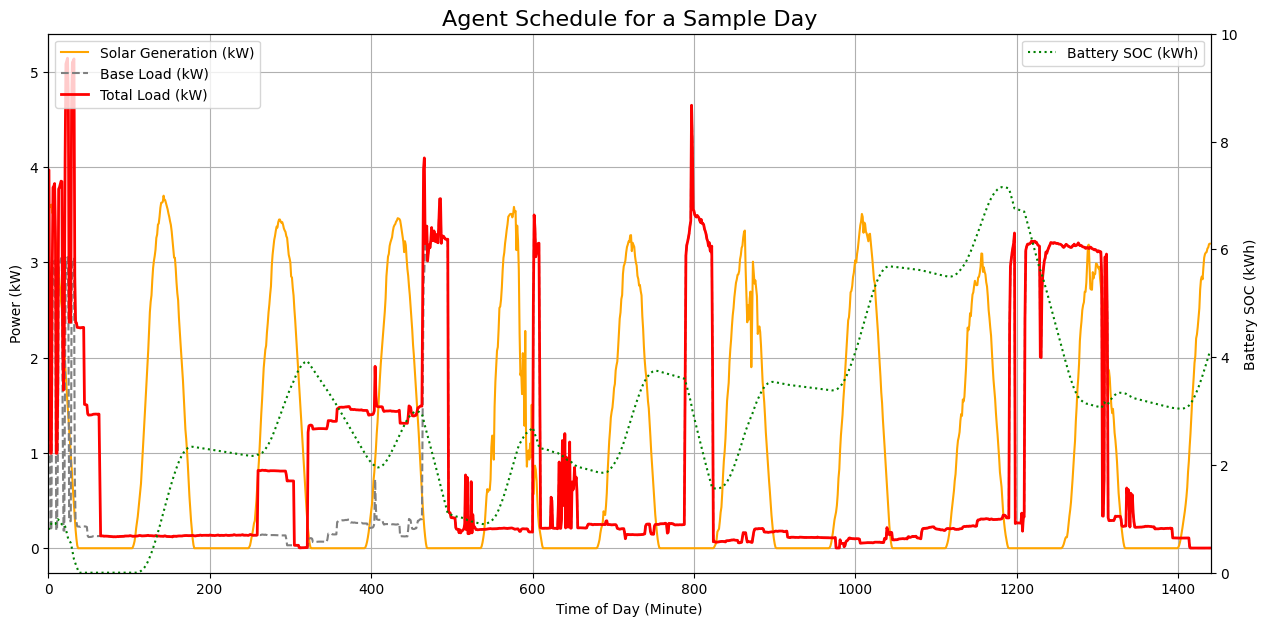

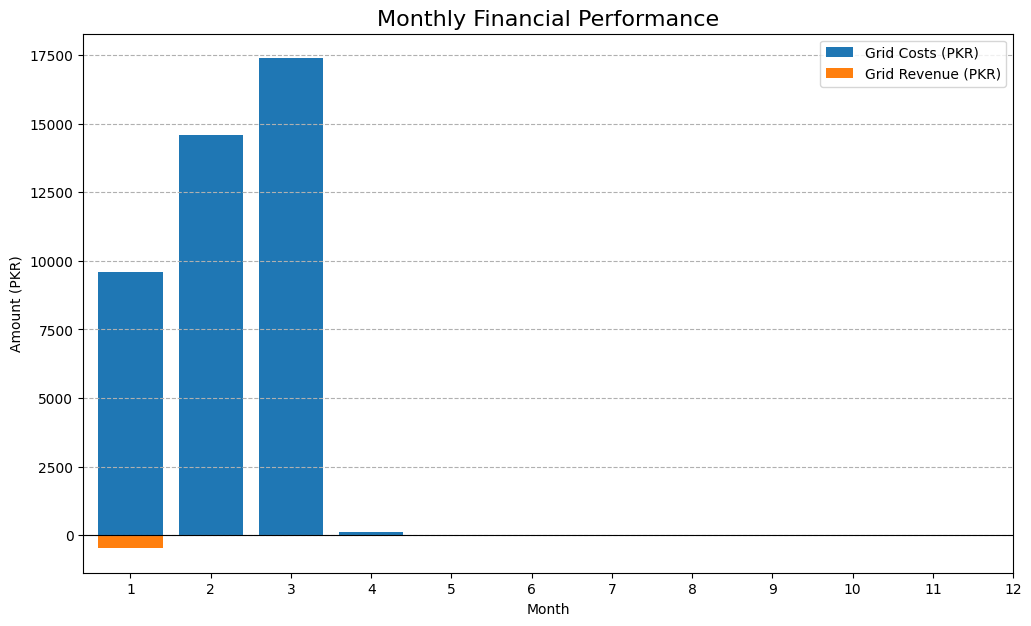

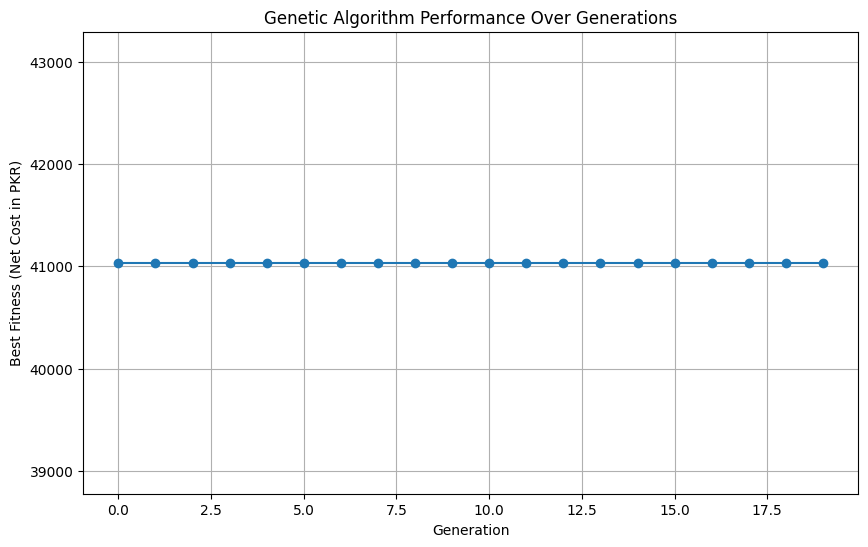

In [9]:
# --- Final Visualizations ---
print("\n--- Generating Final Visualizations ---")

# Add time-based columns for easier plotting
final_results_df['minute_of_day'] = final_results_df.index % (24 * 60)
final_results_df['month'] = (final_results_df.index // (24*60*30)) + 1

# 1. Daily schedule plot for a sample summer day
day_index = 90  # pick the day number you want
sample_day = final_results_df.iloc[1440*day_index : 1440*(day_index+1)]  # full day (1440 steps)
plt.figure(figsize=(15, 7))
ax1 = plt.gca()

# Plot energy loads and generation on primary axis
ax1.plot(sample_day['minute_of_day'], sample_day['solar_kw'], label='Solar Generation (kW)', color='orange')
ax1.plot(sample_day['minute_of_day'], sample_day['base_load_kw'], label='Base Load (kW)', color='gray', linestyle='--')
ax1.plot(sample_day['minute_of_day'], sample_day['base_load_kw'] + sample_day['appliance_load_kw'], label='Total Load (kW)', color='red', linewidth=2)
ax1.set_xlabel('Time of Day (Minute)')
ax1.set_ylabel('Power (kW)')
ax1.legend(loc='upper left')
ax1.grid(True)
ax1.set_xlim(0, 1440)

# Plot battery SOC on secondary axis
ax2 = ax1.twinx()
ax2.plot(sample_day['minute_of_day'], sample_day['battery_soc'], label='Battery SOC (kWh)', color='green', linestyle=':')
ax2.set_ylabel('Battery SOC (kWh)')
ax2.legend(loc='upper right')
ax2.set_ylim(0, final_config['max_battery_kwh'])

plt.title('Agent Schedule for a Sample Day', fontsize=16)
plt.show()

# 2. Monthly cost breakdown
monthly_summary = final_results_df.groupby('month').agg(
    total_cost=('total_cost', 'sum'),
    grid_revenue=('grid_revenue', 'sum')
).reset_index()

plt.figure(figsize=(12, 7))
plt.bar(monthly_summary['month'], monthly_summary['total_cost'], label='Grid Costs (PKR)')
plt.bar(monthly_summary['month'], -monthly_summary['grid_revenue'], label='Grid Revenue (PKR)')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Monthly Financial Performance', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Amount (PKR)')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

# 3. GA Performance Plot
plt.figure(figsize=(10, 6))
plt.plot(range(len(fitness_history)), fitness_history, marker='o')
plt.title('Genetic Algorithm Performance Over Generations')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (Net Cost in PKR)')
plt.grid(True)
plt.show()


--- Generating Visualization: Daily Financial Performance ---


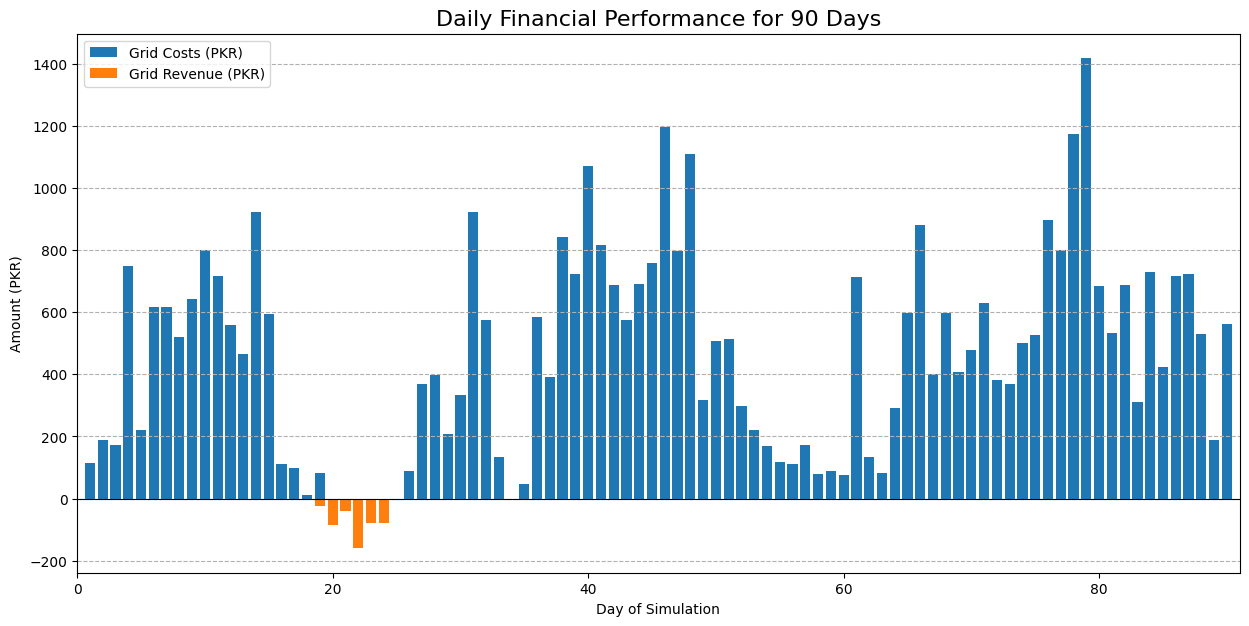

In [10]:
# --- Visualization: Daily Financial Performance for 90 Days ---
print("\n--- Generating Visualization: Daily Financial Performance ---")

# Add a 'day' column to the dataframe for easier grouping
final_results_df['day'] = (final_results_df.index // (24*60)) + 1

# Filter for the first 90 days
ninety_day_results = final_results_df[final_results_df['day'] <= 90]

# Group by day and sum the costs and revenue
daily_summary = ninety_day_results.groupby('day').agg(
    total_cost=('total_cost', 'sum'),
    grid_revenue=('grid_revenue', 'sum')
).reset_index()

# Create the plot
plt.figure(figsize=(15, 7))
plt.bar(daily_summary['day'], daily_summary['total_cost'], label='Grid Costs (PKR)')
plt.bar(daily_summary['day'], -daily_summary['grid_revenue'], label='Grid Revenue (PKR)')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Daily Financial Performance for 90 Days', fontsize=16)
plt.xlabel('Day of Simulation')
plt.ylabel('Amount (PKR)')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.xlim(0, 91) # Set x-axis limit to 90 days
plt.show()


--- Generating Visualization: Appliance Schedule Timeline ---


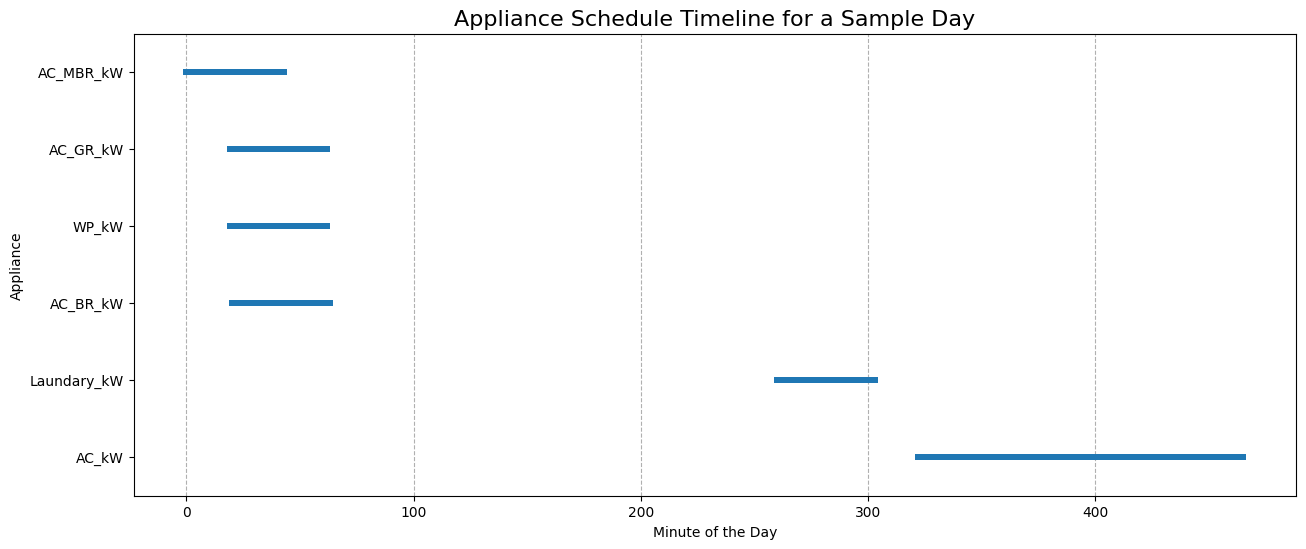

In [11]:
# 4. *** NEW: Appliance Schedule Timeline (Gantt Chart) ***
print("\n--- Generating Visualization: Appliance Schedule Timeline ---")
appliance_names = [app['name'] for app in final_config['appliances']]
schedule_data = []
for i, row in sample_day.iterrows():
    for app_idx, is_running in enumerate(row['running_appliances']):
        if is_running:
            schedule_data.append({'Appliance': appliance_names[app_idx], 'Minute': row['minute_of_day']})

if schedule_data:
    schedule_df = pd.DataFrame(schedule_data)
    
    plt.figure(figsize=(15, 6))
    sns.stripplot(data=schedule_df, x='Minute', y='Appliance', jitter=0, marker='s', size=5)
    plt.title('Appliance Schedule Timeline for a Sample Day', fontsize=16)
    plt.xlabel('Minute of the Day')
    plt.ylabel('Appliance')
    plt.grid(axis='x', linestyle='--')
    plt.show()
else:
    print("No appliances were scheduled on the sample day to plot.")

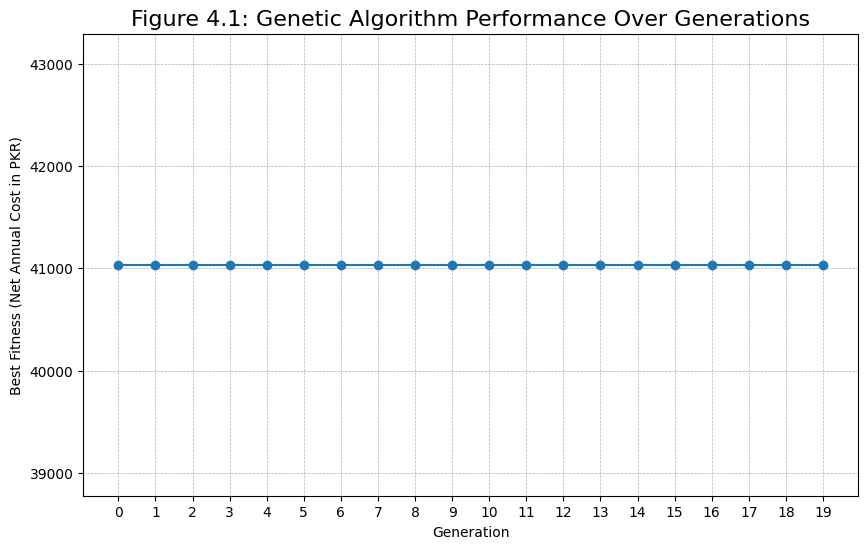

In [12]:
import matplotlib.pyplot as plt

# --- Assumes 'fitness_history' is in memory from the previous GA run ---

plt.figure(figsize=(10, 6))
plt.plot(range(len(fitness_history)), fitness_history, marker='o', linestyle='-')
plt.title('Figure 4.1: Genetic Algorithm Performance Over Generations', fontsize=16)
plt.xlabel('Generation')
plt.ylabel('Best Fitness (Net Annual Cost in PKR)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(len(fitness_history))) # Ensure integer ticks for generations
plt.show()

--- Generating Plot: Cost Per Timestep ---


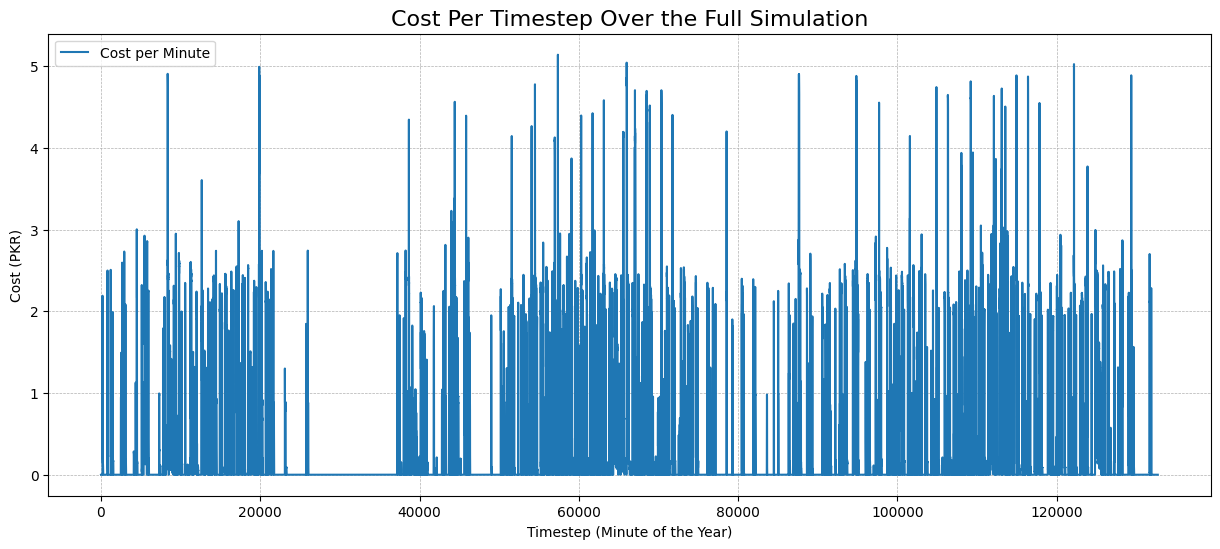

In [13]:
import matplotlib.pyplot as plt

# --- Assumes 'final_results_df' is in your notebook's memory ---

print("--- Generating Plot: Cost Per Timestep ---")

plt.figure(figsize=(15, 6))
plt.plot(final_results_df.index, final_results_df['total_cost'], label='Cost per Minute')
plt.title('Cost Per Timestep Over the Full Simulation', fontsize=16)
plt.xlabel('Timestep (Minute of the Year)')
plt.ylabel('Cost (PKR)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

--- Generating Visualization: Daily Financial Performance for 30 Days ---


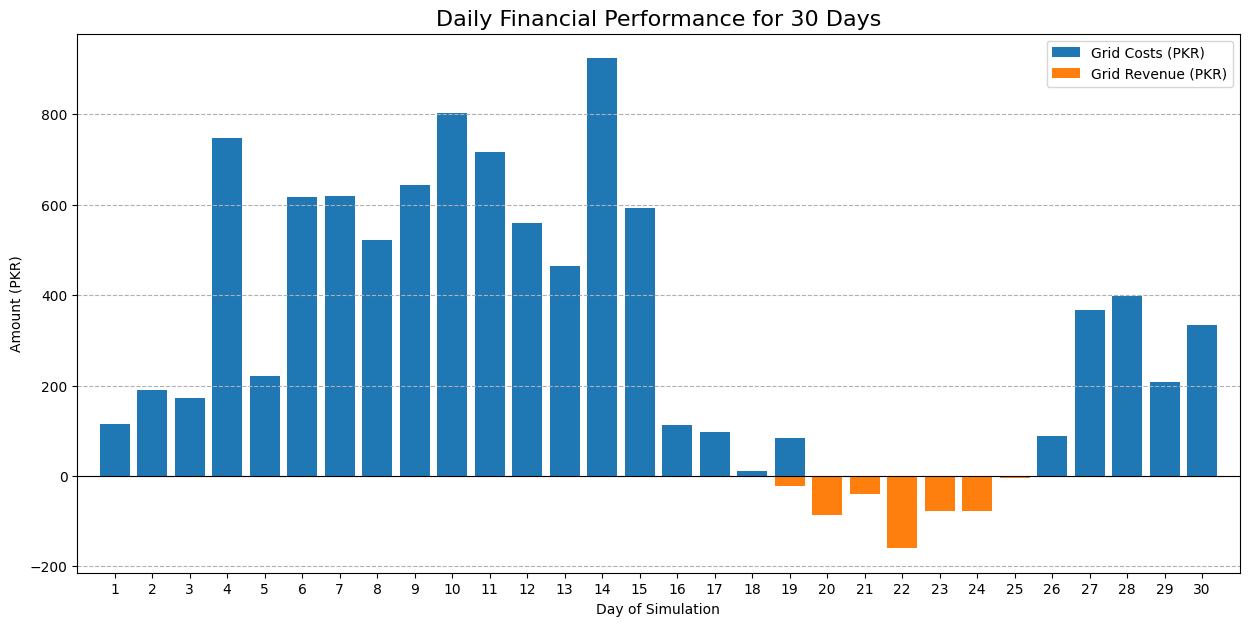

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# --- This code assumes 'final_results_df' is in your notebook's memory ---

print("--- Generating Visualization: Daily Financial Performance for 30 Days ---")

# Add a 'day' column to the dataframe for easier grouping
final_results_df['day'] = (final_results_df.index // (24*60)) + 1

# Filter for the first 30 days of the simulation
thirty_day_results = final_results_df[final_results_df['day'] <= 30]

# Group by day and sum the costs and revenue
daily_summary = thirty_day_results.groupby('day').agg(
    total_cost=('total_cost', 'sum'),
    grid_revenue=('grid_revenue', 'sum')
).reset_index()

# Create the plot
plt.figure(figsize=(15, 7))
plt.bar(daily_summary['day'], daily_summary['total_cost'], label='Grid Costs (PKR)')
plt.bar(daily_summary['day'], -daily_summary['grid_revenue'], label='Grid Revenue (PKR)')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Daily Financial Performance for 30 Days', fontsize=16)
plt.xlabel('Day of Simulation')
plt.ylabel('Amount (PKR)')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.xticks(range(1, 31)) # Set x-axis ticks to show each day
plt.xlim(0, 31) # Set x-axis limit to 30 days
plt.show()

In [15]:
# --- Cost Comparison to Unmanaged Baseline ---
print("\n\n==============================================")
print("===   Cost Comparison: Before vs. After   ===")
print("==============================================")

# Assumed baseline cost from the thesis for a full year of unmanaged consumption.
# The thesis states this is "over 0.15-0.2 million PKR".
baseline_cost_pkr = 175000  # A middle-of-the-range value for comparison.

# The final net bill is already calculated from the optimized agent's performance.
final_net_bill = total_cost - total_revenue

# Calculate the cost reduction and percentage.
cost_reduction = baseline_cost_pkr - final_net_bill
percent_reduction = (cost_reduction / baseline_cost_pkr) * 100

print(f"Annual Baseline Cost (Unmanaged): {baseline_cost_pkr:,.2f} PKR")
print(f"Annual HEMS Bill (After Model):   {final_net_bill:,.2f} PKR")
print("----------------------------------------------")
print(f"Total Cost Reduction:             {cost_reduction:,.2f} PKR")
print(f"Percentage Reduction:             {percent_reduction:.2f}%")
print("==============================================\n")



===   Cost Comparison: Before vs. After   ===
Annual Baseline Cost (Unmanaged): 175,000.00 PKR
Annual HEMS Bill (After Model):   41,220.54 PKR
----------------------------------------------
Total Cost Reduction:             133,779.46 PKR
Percentage Reduction:             76.45%




--- Generating Visualization: Total Energy Consumption ---


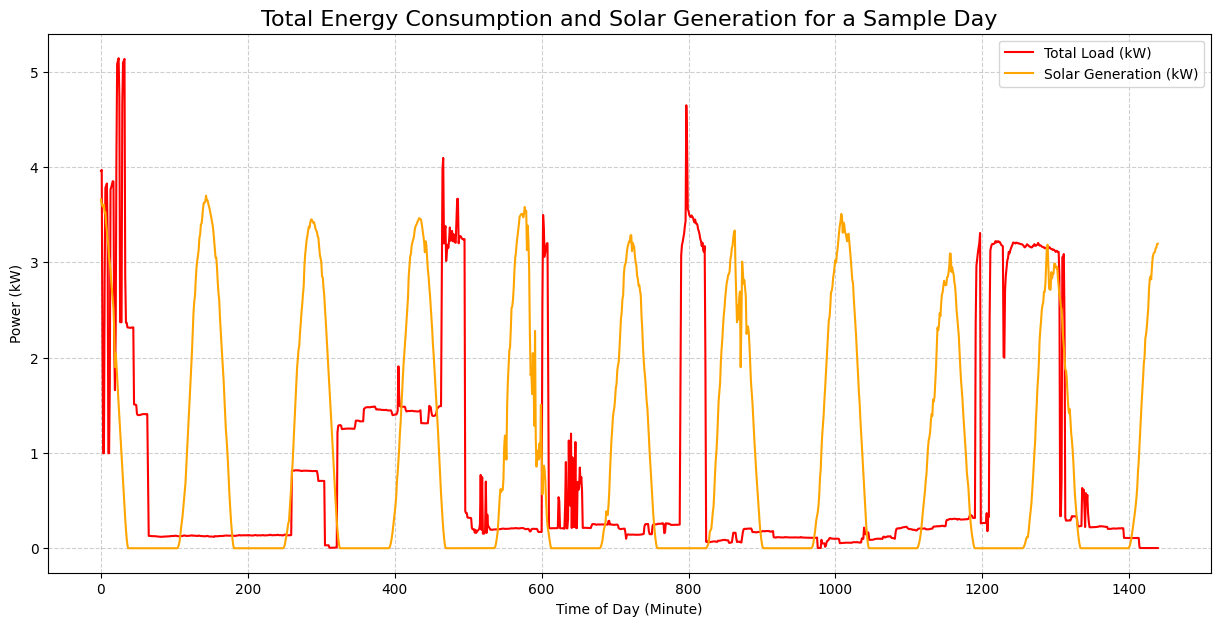

In [20]:
import matplotlib.pyplot as plt

# --- Visualize Total Energy Consumption for a Sample Day ---
print("\n--- Generating Visualization: Total Energy Consumption ---")

# You can change the day_index to visualize any day of the simulation
day_index = 90
sample_day = final_results_df.iloc[1440*day_index : 1440*(day_index+1)]

# Calculate the total load for each minute
sample_day['total_load_kw'] = sample_day['base_load_kw'] + sample_day['appliance_load_kw']

plt.figure(figsize=(15, 7))
plt.plot(sample_day['minute_of_day'], sample_day['total_load_kw'], label='Total Load (kW)', color='red')
plt.plot(sample_day['minute_of_day'], sample_day['solar_kw'], label='Solar Generation (kW)', color='orange')
plt.title('Total Energy Consumption and Solar Generation for a Sample Day', fontsize=16)
plt.xlabel('Time of Day (Minute)')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()